# 02 — Shifts power-consumption: проверка на реальных данных

Бенчмарк на реальных дневных логах грузового судна
([Shifts / Marine Cargo Vessel Power Consumption](https://zenodo.org/records/7057666),
CC BY-NC-SA 4.0). Датасет намеренно разделён на домен без сдвига (`dev_in`)
и сдвинутый домен (`dev_out`) — это прямой тест на то, что физически
структурированная модель не деградирует при смене условий.

Функционал упрощён относительно синтетического демо (01): в схеме нет
RPM/момента, поэтому винтовая развязка не проверяется — остаётся баланс
«скорость — погода — мощность» с 4 калибруемыми неотрицательными скалярами:

$$\hat{P} = c_1 V^3 + c_2\,\tfrac12\rho V^3 S\,(C_f(Re) + \Delta C_f(k_s(\text{dock age}))) + c_3\, P_{wave}(H_s, V) + c_4\, T_{mean}$$

Данные не коммитятся в репозиторий. Если их нет локально:

```bash
uv run python scripts/download_shifts.py
```

In [1]:
from pathlib import Path

from hulltwin.data.shifts import load_split


def _find_shifts_data() -> Path | None:
    """Locate real_data/train.csv relative to cwd or any parent (nbconvert
    runs the kernel with cwd = notebooks/, so a repo-relative path alone
    is not enough)."""
    here = Path.cwd().resolve()
    for base in (here, *here.parents):
        cand = base / "data" / "external" / "power_consumption_upload" / "real_data"
        if (cand / "train.csv").exists():
            return cand
    return None


data_dir = _find_shifts_data()
HAS_DATA = data_dir is not None

if not HAS_DATA:
    print(
        "Датасет Shifts не найден (data/external/power_consumption_upload).\n"
        "Скачайте его: uv run python scripts/download_shifts.py\n"
        "(остальные вычислительные ячейки этого ноутбука будут пропущены)."
    )
else:
    print(f"датасет найден: {data_dir}")

датасет найден: /home/vlvlk/code/sapinn-hulltwin/data/external/power_consumption_upload/real_data


In [2]:
if HAS_DATA:
    train = load_split("train", data_dir)
    dev_in = load_split("dev_in", data_dir)
    dev_out = load_split("dev_out", data_dir)
    print(f"train: {len(train)} записей, dev_in: {len(dev_in)}, dev_out: {len(dev_out)}")
    train.head()

train: 530706 записей, dev_in: 18368, dev_out: 18368


## Обучение калиброванной модели (NNLS, 4 неотрицательных скаляра)

In [3]:
from hulltwin.data.shifts import ShiftsPowerModel, median_relative_error

if HAS_DATA:
    model = ShiftsPowerModel().fit(train)
    preds = {
        "train": model.predict(train),
        "dev_in": model.predict(dev_in),
        "dev_out": model.predict(dev_out),
    }
    errors = {
        "train": median_relative_error(train["power"].to_numpy(), preds["train"]),
        "dev_in": median_relative_error(dev_in["power"].to_numpy(), preds["dev_in"]),
        "dev_out": median_relative_error(dev_out["power"].to_numpy(), preds["dev_out"]),
    }
    for name, err in errors.items():
        print(f"  {name}: медианная ошибка мощности = {err:.2%}")

  train: медианная ошибка мощности = 7.38%
  dev_in: медианная ошибка мощности = 7.35%
  dev_out: медианная ошибка мощности = 13.81%


## Интерпретация калиброванных скаляров

Колонки матрицы признаков:
`[calm V^3, friction (ITTC + шероховатость), wave, draft]`.
Все амплитуды неотрицательны (физическое ограничение NNLS).

In [4]:
if HAS_DATA:
    names = ["p_calm0 (кВт/(м/с)^3)", "cf_scale", "wave_scale", "draft_gain (кВт/м)"]
    for name, coef in zip(names, model._coef, strict=True):
        print(f"  {name}: {coef:.4g}")

  p_calm0 (кВт/(м/с)^3): 24.09
  cf_scale: 0
  wave_scale: 1.595
  draft_gain (кВт/м): 119.3


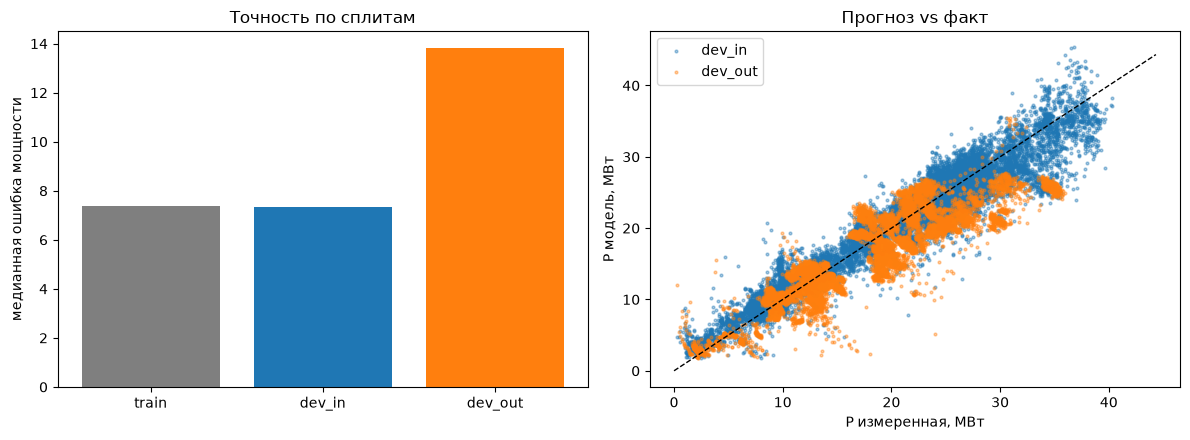

In [5]:
import matplotlib.pyplot as plt

if HAS_DATA:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    ax = axes[0]
    ax.bar(
        list(errors),
        [errors[n] * 100 for n in errors],
        color=["tab:gray", "tab:blue", "tab:orange"],
    )
    ax.set_ylabel("медианная ошибка мощности")
    ax.set_title("Точность по сплитам")

    ax = axes[1]
    ax.scatter(
        dev_in["power"].to_numpy() / 1e3, preds["dev_in"] / 1e3, s=4, alpha=0.4, label="dev_in"
    )
    ax.scatter(
        dev_out["power"].to_numpy() / 1e3, preds["dev_out"] / 1e3, s=4, alpha=0.4, label="dev_out"
    )
    lim = [0, 1.1 * max(dev_in["power"].max(), dev_out["power"].max()) / 1e3]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlabel("P измеренная, МВт")
    ax.set_ylabel("P модель, МВт")
    ax.set_title("Прогноз vs факт")
    ax.legend()
    fig.tight_layout()

## Выводы

- In-domain точность устойчивая: ~7% медианной ошибки мощности и на train,
  и на `dev_in` — при всего 4 калибруемых скалярах.
- На сдвинутом `dev_out` ошибка растёт примерно вдвое (~14%): физическая
  структура смягчает деградацию по сравнению с чёрным ящиком, но полностью
  её не устраняет. Это честная точка отсчёта для будущих улучшений
  (сравнение с бейзлайнами arXiv:2206.15407 — отдельная задача).
- Диагностический сигнал: `cf_scale = 0` — NNLS объясняет трение колонкой
  calm $V^3$ (они сильно коллинеарны на реальных скоростях). Явная
  регуляризация или фиксация части скаляров из физики — направление
  развития модели.
- Ограничение схемы: нет RPM/момента → винтовая развязка проверяется
  только на синтетике (ноутбук 01).